# Clima / IoT: Predicción de Series (Forecasting)

## Sinergia Topológica con Takens Embedding + Betti Curves

Tenemos la serie diaria de temperatura de Delhi (2013 a 2017, dataset de Kaggle) y queremos predecir la temperatura de mañana T_{t+1}. Nuestra apuesta es que si a los lags clásicos les sumamos features topológicas sacadas de ventanas de 60 días, el modelo aguanta mejor cuando faltan datos.

Para desarrollar el presente notebook, nos apoyamos directamente en los notebooks del curso. De N5 tomamos delay_embedding, average_mutual_information y fnn_fraction para reconstruir el atractor y elegir tau y d. De N2 usamos ripser y plot_diagrams para los diagramas de persistencia. De N3 la idea de la Betti Curve como vectorización del diagrama. De N4 el finite_points y wasserstein_distance para comparar diagramas entre datos limpios y dañados. No usamos N7 (Mapper) porque devuelve un grafo y no vectores numéricos que el regresor pueda consumir.

El notebook lo dividimos en tres partes: (1) el juguete de intuición donde reconstruimos el atractor, (2) el reto principal donde armamos features topológicas por ventana y corremos el benchmark baseline vs topológico, y (3) el experimento de missing data donde rompemos el 15% de la serie y comparamos la degradación de ambos modelos.

### Imports

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from ripser import ripser
from persim import plot_diagrams, wasserstein as wasserstein_distance
import warnings
warnings.filterwarnings("ignore")

### Funciones copiadas de los notebooks del curso

Estas funciones vienen tal cual de N5 y N4, sin modificaciones.

In [17]:
# N5
# Takens Embedding: construye la nube de puntos en R^d a partir de la serie
# Cada punto es (x_t, x_{t+tau}, ..., x_{t+(d-1)tau})
def delay_embedding(x, tau=10, dim=3):
    x = np.asarray(x)
    m = len(x) - (dim - 1) * tau
    if m <= 0:
        raise ValueError("Serie muy corta para τ y d elegidos.")
    emb = np.empty((m, dim))
    for j in range(dim):
        emb[:, j] = x[j * tau:j * tau + m]
    return emb

# N5
# AMI: información mutua entre x_t y x_{t+lag}, nos sirve para elegir tau
def average_mutual_information(x, max_lag=80, bins=32):
    x = np.asarray(x)
    ami = np.zeros(max_lag)
    for lag in range(1, max_lag + 1):
        x1, x2 = x[:-lag], x[lag:]
        h2d, _, _ = np.histogram2d(x1, x2, bins=bins)
        pxy = h2d / np.sum(h2d)
        px = pxy.sum(axis=1, keepdims=True)
        py = pxy.sum(axis=0, keepdims=True)
        mask = pxy > 0
        ami[lag - 1] = np.sum(pxy[mask] * np.log(pxy[mask] / (px @ py)[mask]))
    return ami

# El tau óptimo es el primer mínimo local de la AMI
def first_local_minimum(y):
    for i in range(1, len(y) - 1):
        if y[i] < y[i - 1] and y[i] < y[i + 1]:
            return i + 1
    return np.argmin(y) + 1

# N5
# FNN: fracción de vecinos falsos al pasar de dim d a dim d+1
# La d buena es donde esto cae por debajo del 2%
def fnn_fraction(x, tau, dim, rtol=15.0, atol=2.0, max_points=1800):
    emb_d = delay_embedding(x, tau=tau, dim=dim)
    emb_d1 = delay_embedding(x, tau=tau, dim=dim + 1)
    m = min(len(emb_d1), max_points)
    emb_d, emb_d1 = emb_d[:m], emb_d1[:m]
    nbrs = NearestNeighbors(n_neighbors=2).fit(emb_d)
    dist_d, idx = nbrs.kneighbors(emb_d)
    nn_index = idx[:, 1]
    d_d = np.maximum(dist_d[:, 1], 1e-12)
    extra = np.abs(emb_d1[:, -1] - emb_d1[nn_index, -1])
    ratio = extra / d_d
    scale = np.std(x)
    false_nn = (ratio > rtol) | ((d_d**2 + extra**2)**0.5 / scale > atol)
    return false_nn.mean()

# N4
# Filtra los puntos del diagrama que tienen death finito (los infinitos no sirven para Wasserstein)
def finite_points(dgm):
    if len(dgm) == 0:
        return np.zeros((0, 2))
    return dgm[np.isfinite(dgm[:, 1])]

## Carga del dataset de Kaggle

El dataset es Daily Climate time series data. Lo bajamos con kagglehub.

In [18]:
import kagglehub
import os

# Bajamos el dataset de Kaggle
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
df = pd.read_csv(os.path.join(path, "DailyDelhiClimateTrain.csv"))

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   str    
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), str(1)
memory usage: 57.2 KB


In [20]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [21]:

df["date"] = pd.to_datetime(df["date"])
temp = df["meantemp"].values.astype(float)

print(f"Días: {len(temp)}, rango: {temp.min():.1f}°C a {temp.max():.1f}°C")

Días: 1462, rango: 6.0°C a 38.7°C


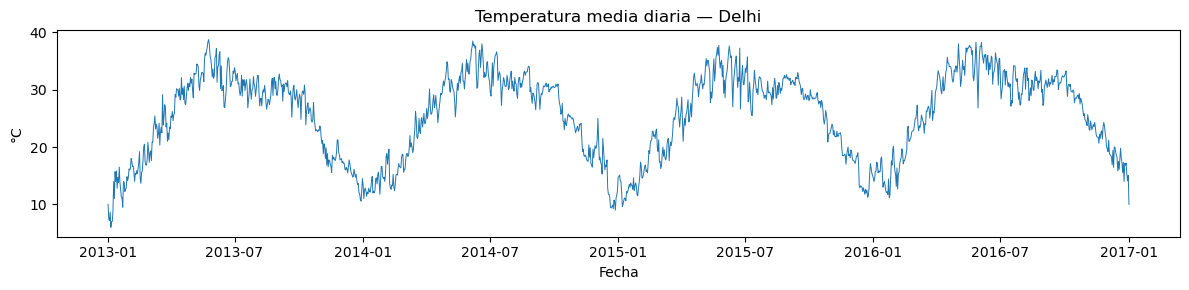

In [22]:
# Graficamos la serie para ver si se nota el ciclo anual
plt.figure(figsize=(12, 3))
plt.plot(df["date"], temp, lw=0.7)
plt.xlabel("Fecha"); plt.ylabel("°C"); plt.title("Temperatura media diaria — Delhi")
plt.tight_layout(); plt.show()

## Parte 1. El Juguete de Intuición

Aplicamos Takens Embedding a la serie completa. Si el ciclo anual se refleja en la geometría, esperamos ver un loop cerrado (toro difuso) en 3D. Ese loop, cuando lo pasemos por Ripser, debería dejar al menos un feature de H_1 con persistencia alta.

Primero elegimos los hiperparámetros. Tomamos tau como el primer mínimo local de la AMI (N5) y d como la primera dimensión donde FNN cae por debajo del 2% (N5).

In [23]:
# Calculamos la AMI hasta 80 días y tomamos el primer mínimo local como tau
ami = average_mutual_information(temp, max_lag=80, bins=32)
tau_star = first_local_minimum(ami)
print(f"τ* = {tau_star} días")

τ* = 17 días


In [24]:
# Probamos d de 1 a 8 y nos quedamos con el primer d donde FNN < 2%
dims = np.arange(1, 9)
fnn = np.array([fnn_fraction(temp, tau=tau_star, dim=d) for d in dims])
below = np.where(fnn < 0.02)[0]
d_star = int(dims[below[0]]) if len(below) else int(dims[np.argmin(fnn)])
print(f"d* = {d_star}")

d* = 4


Con tau y d construimos el encaje y lo visualizamos en 3D (proyectando a las tres primeras coordenadas si d > 3).

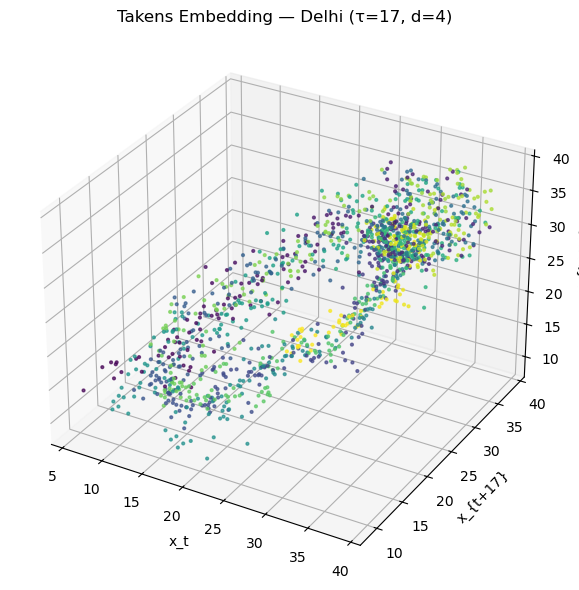

In [25]:
# Construimos el encaje de Takens con los parámetros que salieron
# Si d* > 3 igual visualizamos solo las primeras 3 coordenadas
emb_full = delay_embedding(temp, tau=tau_star, dim=max(3, d_star))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
c = np.linspace(0, 1, len(emb_full))  # color por orden temporal
ax.scatter(emb_full[:, 0], emb_full[:, 1], emb_full[:, 2], s=4, c=c, cmap="viridis", alpha=0.7)
ax.set_xlabel("x_t"); ax.set_ylabel(f"x_{{t+{tau_star}}}"); ax.set_zlabel(f"x_{{t+{2*tau_star}}}")
ax.set_title(f"Takens Embedding — Delhi (τ={tau_star}, d={max(3, d_star)})")
plt.tight_layout(); plt.show()

Confirmamos la existencia del loop cuantitativamente con Ripser (N2). Submuestreamos el encaje porque Ripser es O(n^3).

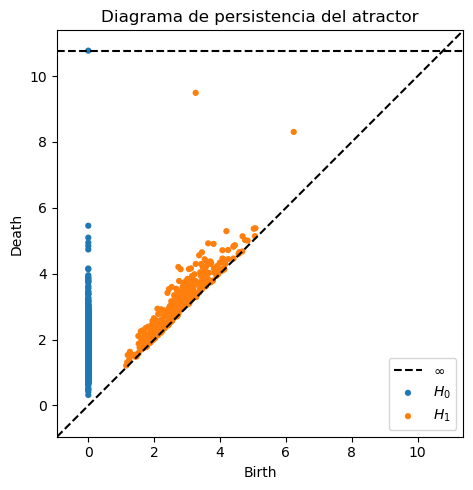

Persistencia máxima H1: 6.231
Features H1 con persistencia > 0.25: 191


In [26]:
# Submuestreamos porque Ripser se pone lento si hay muchos puntos
emb_sub = emb_full[::2][:800]
dgms = ripser(emb_sub, maxdim=1)["dgms"]

fig, ax = plt.subplots(figsize=(5, 5))
plot_diagrams(dgms, show=False, ax=ax)
ax.set_title("Diagrama de persistencia del atractor")
plt.tight_layout(); plt.show()

# Revisamos si hay algún loop con persistencia alta (eso confirma que sí hay ciclo)
h1 = finite_points(dgms[1])
if len(h1) > 0:
    pers = h1[:, 1] - h1[:, 0]
    print(f"Persistencia máxima H1: {pers.max():.3f}")
    print(f"Features H1 con persistencia > 0.25: {(pers > 0.25).sum()}")

## Parte 2. Feature engineering topológico y benchmark

Ahora trabajamos por ventana. Para cada día t tomamos los últimos 60 días como ventana, le calculamos Takens, diagrama de persistencia y de ahí la Betti Curve. La Betti Curve es la función beta_q(r) = número de features de dimensión q vivos en r (N3). La discretizamos en n_bins valores y así cada ventana nos da un vector numérico.
Como las ventanas son cortas, bajamos tau proporcionalmente y fijamos d=3 para que sea viable.
Implementamos la Betti Curve manualmente porque gtda.diagrams.BettiCurve tiene un bug de compatibilidad con scikit-learn reciente, y haciéndola a mano la definición queda explícita.

In [27]:
N_BINS = 15

# Nuestra Betti Curve manual: para cada valor de filtración t contamos
# cuántos features (de H0 y H1) están vivos y lo apilamos en un vector
def manual_betti_curve(dgms, n_bins=N_BINS):
    pts = [(b, d, k) for k, dgm in enumerate(dgms) for b, d in dgm if np.isfinite(d)]
    if not pts:
        return np.zeros(n_bins * 2)
    arr = np.array(pts)
    t_vals = np.linspace(arr[:, 0].min(), arr[:, 1].max(), n_bins)
    curves = []
    for k in [0, 1]:  # H0 y H1
        mask = arr[:, 2] == k
        if not mask.any():
            curves.append(np.zeros(n_bins))
            continue
        pk = arr[mask]
        # Un feature está vivo en t si birth <= t < death
        curves.append(np.array([np.sum((pk[:, 0] <= t) & (pk[:, 1] > t)) for t in t_vals], dtype=float))
    return np.concatenate(curves)

# Pipeline de features por ventana: Takens → Ripser → Betti
def betti_features(window, tau, dim):
    try:
        emb = delay_embedding(window, tau=tau, dim=dim)
        if len(emb) < 10:
            return np.zeros(N_BINS * 2)
        return manual_betti_curve(ripser(emb, maxdim=1)["dgms"])
    except Exception:
        return np.zeros(N_BINS * 2)

Armamos el dataset. Empezamos en t=60 porque necesitamos 60 días previos, y paramos en el penúltimo día porque necesitamos t+1 como target. Los lags son los 7 valores anteriores.

In [28]:
WINDOW = 60# ventana histórica de 60 días
N_LAGS = 7 # últimos 7 días como lags
TAU_W = max(3, tau_star // 4)   # tau más chico para que Takens entre en la ventana
DIM_W = 3

# Por cada día t armamos: target (t+1), los 7 lags y el vector de Betti de la ventana
lags_all, betti_all, y_all = [], [], []
for t in range(WINDOW, len(temp) - 1):
    y_all.append(temp[t + 1])
    lags_all.append([temp[t - i] for i in range(N_LAGS)])
    betti_all.append(betti_features(temp[t - WINDOW + 1:t + 1], TAU_W, DIM_W))

X_lags = np.array(lags_all)
X_betti = np.array(betti_all)
y = np.array(y_all)
print(f"X_lags {X_lags.shape}, X_betti {X_betti.shape}, y {y.shape}")

X_lags (1401, 7), X_betti (1401, 30), y (1401,)


Split temporal 80/20 (nunca revolvemos, es serie), y entrenamos los dos modelos con los mismos hiperparámetros. El único cambio entre baseline y topológico es qué features recibe.

In [29]:
# Split 80/20 en orden temporal (nada de shuffle porque es serie)
split = int(0.8 * len(y))
X_train_base, X_test_base = X_lags[:split], X_lags[split:]
X_comb = np.hstack([X_lags, X_betti])
X_train_topo, X_test_topo = X_comb[:split], X_comb[split:]
y_train, y_test = y[:split], y[split:]

# Mismos hiperparámetros para los dos modelos, lo único que cambia son los features
params = dict(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, verbosity=0)

model_base = XGBRegressor(**params).fit(X_train_base, y_train)
model_topo = XGBRegressor(**params).fit(X_train_topo, y_train)

rmse_b = np.sqrt(mean_squared_error(y_test, model_base.predict(X_test_base)))
rmse_t = np.sqrt(mean_squared_error(y_test, model_topo.predict(X_test_topo)))

print(f"RMSE baseline (lags): {rmse_b:.4f}")
print(f"RMSE topológico (lags + Betti): {rmse_t:.4f}")

RMSE baseline (lags): 1.6990
RMSE topológico (lags + Betti): 1.7097


Con datos completos los dos modelos suelen quedar cerca, porque los lags ya cargan bastante información reciente. El punto del ejercicio se ve en la siguiente parte.

## Parte 3. Missing data

Simulamos caída de sensores borrando el 15% de los valores al azar y rellenando por interpolación lineal (un sensor real no entrega NaN, entrega el último valor o una interpolación). Los targets siguen siendo los valores reales: medimos qué tanto se degrada la predicción cuando las features se construyen con datos sucios.

In [30]:
# Simulamos sensores caídos: borramos 15% al azar y rellenamos con interpolación lineal
np.random.seed(123)
temp_dmg = temp.copy()
idx = np.random.choice(len(temp_dmg), int(0.15 * len(temp_dmg)), replace=False)
temp_dmg[idx] = np.nan
temp_dmg[idx] = 0

In [31]:
# Rearmamos los features pero con la serie dañada
# OJO: los targets siguen siendo los valores REALES (no los interpolados)
lags_d, betti_d = [], []
for t in range(WINDOW, len(temp_dmg) - 1):
    lags_d.append([temp_dmg[t - i] for i in range(N_LAGS)])
    betti_d.append(betti_features(temp_dmg[t - WINDOW + 1:t + 1], TAU_W, DIM_W))

X_lags_d = np.array(lags_d)
X_betti_d = np.array(betti_d)

X_train_base_d, X_test_base_d = X_lags_d[:split], X_lags_d[split:]
X_comb_d = np.hstack([X_lags_d, X_betti_d])
X_train_topo_d, X_test_topo_d = X_comb_d[:split], X_comb_d[split:]

m_b_d = XGBRegressor(**params).fit(X_train_base_d, y_train)
m_t_d = XGBRegressor(**params).fit(X_train_topo_d, y_train)

rmse_b_d = np.sqrt(mean_squared_error(y_test, m_b_d.predict(X_test_base_d)))
rmse_t_d = np.sqrt(mean_squared_error(y_test, m_t_d.predict(X_test_topo_d)))

print(f"RMSE baseline dañado: {rmse_b_d:.4f}  (diferencia = {rmse_b_d - rmse_b:.4f})")
print(f"RMSE topológico dañado: {rmse_t_d:.4f}  (diferencia = {rmse_t_d - rmse_t:.4f})")

RMSE baseline dañado: 1.8415  (diferencia = 0.1425)
RMSE topológico dañado: 1.8352  (diferencia = 0.1255)


Como cierre, comparamos los diagramas de persistencia original y dañado con distancia de Wasserstein (N4). Si la distancia sale baja, confirma que la topología es estable bajo pequeñas perturbaciones (teorema de estabilidad de diagramas) y eso explica por qué la Betti Curve aguanta mejor que los lags crudos.

In [32]:
# Comparamos el diagrama H1 original vs el dañado con Wasserstein
# Si la distancia es chica, la topología del atractor aguanta el missing data
emb_o = delay_embedding(temp[:500], tau=tau_star, dim=d_star)[:400]
emb_d = delay_embedding(temp_dmg[:500], tau=tau_star, dim=d_star)[:400]
dgm_o = ripser(emb_o, maxdim=1)["dgms"]
dgm_d = ripser(emb_d, maxdim=1)["dgms"]
w = wasserstein_distance(finite_points(dgm_o[1]), finite_points(dgm_d[1]))
print(f"Wasserstein entre H1 original y dañado: {w:.4f}")

Wasserstein entre H1 original y dañado: 65.5628


Si la degradación del baseline es mayor que la del topológico y la distancia de Wasserstein es pequeña, cerramos el argumento: la información topológica de la ventana apenas cambió con el daño, así que el modelo que la usa pierde menos calidad.